In [37]:
# !pip install torch

In [38]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, 
    classification_report,
    confusion_matrix, 
    precision_score, 
    recall_score, 
    fbeta_score
)
from pathlib import Path
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# 파일 불러오기 
'''train_df = pd.read_csv(r"../../data/processed/ADASYN/data_train_adasyn.csv")
valid_df = pd.read_csv(r"../../data/processed/ADASYN/data_valid.csv")
test_df = pd.read_csv(r"../../data/processed/ADASYN/data_test.csv")

target = "Risk_Label"

# Split features/target
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_valid = valid_df.drop(columns=[target])
y_valid = valid_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]


print("train shape:", X_train.shape, y_train.shape)
print("valid shape:", X_valid.shape, y_valid.shape)
print("test shape:", X_test.shape, y_test.shape)'''

'train_df = pd.read_csv(r"../../data/processed/ADASYN/data_train_adasyn.csv")\nvalid_df = pd.read_csv(r"../../data/processed/ADASYN/data_valid.csv")\ntest_df = pd.read_csv(r"../../data/processed/ADASYN/data_test.csv")\n\ntarget = "Risk_Label"\n\n# Split features/target\nX_train = train_df.drop(columns=[target])\ny_train = train_df[target]\n\nX_valid = valid_df.drop(columns=[target])\ny_valid = valid_df[target]\n\nX_test = test_df.drop(columns=[target])\ny_test = test_df[target]\n\n\nprint("train shape:", X_train.shape, y_train.shape)\nprint("valid shape:", X_valid.shape, y_valid.shape)\nprint("test shape:", X_test.shape, y_test.shape)'

### 파일불러오기

In [40]:
# 파일 불러오기 
df = pd.read_csv(r"../../data/processed/data_selected.csv")
target = "Risk_Label"

df.drop("Date", axis=1, inplace=True)
# df[target] = df[target].map({"Low Risk": 0, "High Risk": 1})

n_total = len(df)
n_train = int(n_total * 0.5)
n_valid = int(n_total * 0.3)
n_test = n_total - n_train - n_valid

train_df = df.iloc[:n_train].reset_index(drop=True)
valid_df = df.iloc[n_train : n_train + n_valid].reset_index(drop=True)
test_df = df.iloc[n_train + n_valid :].reset_index(drop=True)

print(f"total rows: {n_total}, train: {len(train_df)}, valid: {len(valid_df)}, test: {len(test_df)}")

# Split features/target
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_valid = valid_df.drop(columns=[target])
y_valid = valid_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print("train shape:", X_train.shape, y_train.shape)
print("valid shape:", X_valid.shape, y_valid.shape)
print("test shape:", X_test.shape, y_test.shape)

total rows: 4108, train: 2054, valid: 1232, test: 822
train shape: (2054, 9) (2054,)
valid shape: (1232, 9) (1232,)
test shape: (822, 9) (822,)


### TCN 

In [41]:
# ---------------
# 1) Tensor 준비 (채널=feature수, 길이=seq_len)
# ---------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Date 컬럼 제거
'''
X_train = X_train.drop(columns=["Date"], errors="ignore")
X_valid = X_valid.drop(columns=["Date"], errors="ignore")
X_test = X_test.drop(columns=["Date"], errors="ignore")

# Date가 index였던 경우 대비
X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
'''

# 원본 2D 배열: (num_samples, num_features)
X_train_np = X_train.values.astype(np.float32)
X_valid_np = X_valid.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_valid_np = y_valid.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

num_features = X_train_np.shape[1]
print("num_features:", num_features)

def make_sequence_dataset(X, y, seq_len):
    """
    X: (N, F) -> X_seq: (N-seq_len+1, F, seq_len)
    y는 각 윈도우의 마지막 시점 레이블을 사용.
    """
    if len(X) < seq_len:
        raise ValueError(f"len(X)={len(X)} is smaller than seq_len={seq_len}")

    X_seq, y_seq = [], []
    for end_idx in range(seq_len - 1, len(X)):
        start_idx = end_idx - seq_len + 1
        window = X[start_idx:end_idx + 1]          # (seq_len, F)
        X_seq.append(window.T)                     # (F, seq_len)
        y_seq.append(y[end_idx])

    X_seq = torch.tensor(np.stack(X_seq), dtype=torch.float32)
    y_seq = torch.tensor(np.array(y_seq), dtype=torch.float32)
    return X_seq, y_seq

# -----------------------------
# 2) TCN 블록/모델 정의
# -----------------------------
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, X):
        return X[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else X


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNClassifier(nn.Module):
    def __init__(self, input_channels, channels=(8, 16, 32), kernel_size=3, dropout=0.1):
        super().__init__()
        layers = []
        in_ch = input_channels

        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], 1)

    def forward(self, x):
        h = self.tcn(x)
        h_last = h[:, :, -1]
        logit = self.head(h_last).squeeze(1)
        return logit



device: cpu
num_features: 9


In [42]:
# -----------------------------
# 3) 학습 + 하이퍼파라미터 탐색
# -----------------------------

def build_loaders(seq_len, batch_size):
    X_train_t, y_train_t = make_sequence_dataset(X_train_np, y_train_np, seq_len)
    X_valid_t, y_valid_t = make_sequence_dataset(X_valid_np, y_valid_np, seq_len)
    X_test_t, y_test_t = make_sequence_dataset(X_test_np, y_test_np, seq_len)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(TensorDataset(X_valid_t, y_valid_t), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

model = TCNClassifier(input_channels=num_features).to(device)
optimizer = Adam(model.parameters(), lr=0.0005) #################optimizer#################

def run_epoch(model, loader, criterion, optimizer=None, threshold=0.5):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    preds_all, ys_all = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float() ##########threshold##########

        preds_all.append(preds.detach().cpu())
        ys_all.append(yb.detach().cpu())

    y_true = torch.cat(ys_all).numpy()
    y_pred = torch.cat(preds_all).numpy()

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    g_mean = np.sqrt(recall * specificity)

    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, g_mean

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    y_true_all, y_pred_all = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long().cpu().numpy()

        y_pred_all.append(preds)
        y_true_all.append(yb.numpy().astype(int))

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    return y_true, y_pred

def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    g_mean = float(np.sqrt(sensitivity * specificity))

    return {
        "accuracy": acc,
        "f2": f2,
        "recall": recall,
        "spec": specificity,
        "precision": precision,
        "g_mean": g_mean,
    }

def print_metrics(title, metrics):
    print(f"\n[{title}] Metrics")
    print(f"accuracy : {metrics['accuracy']:.4f}")
    print(f"f2       : {metrics['f2']:.4f}")
    print(f"recall   : {metrics['recall']:.4f}")
    print(f"precision: {metrics['precision']:.4f}")
    print(f"specificity: {metrics['spec']:.4f}")
    print(f"g-mean   : {metrics['g_mean']:.4f}")

# Search Space
seq_len_grid = [4, 5]
batch_grid = [16]
threshold_grid = np.arange(0.1, 0.7, 0.1)
num_epochs = 30

search_results = []
best_result = None
best_valid_gm = -1.0

for seq_len in seq_len_grid:
    for batch_size in batch_grid:
        for threshold in threshold_grid:
            train_loader, valid_loader, test_loader = build_loaders(seq_len, batch_size)

            model = TCNClassifier(input_channels=num_features, channels=(8, 16, 32), kernel_size=3, dropout=0.2).to(device)
            criterion = nn.BCEWithLogitsLoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

            local_best_gm = -1.0
            local_best_state = None

            for epoch in range(1, num_epochs + 1):
                train_loss, train_gm = run_epoch(model, train_loader, criterion, optimizer=optimizer)
                valid_loss, valid_gm = run_epoch(model, valid_loader, criterion, optimizer=None)

                if valid_gm > local_best_gm:
                    local_best_gm = valid_gm
                    local_best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            model.load_state_dict(local_best_state)
            model.to(device)

            valid_true, valid_pred = predict_loader(model, valid_loader)
            test_true, test_pred = predict_loader(model, test_loader) 
            valid_metrics = calculate_metrics(valid_true, valid_pred)
            test_metrics = calculate_metrics(test_true, test_pred)

            row = {
            "seq_len": seq_len,
            "batch_size": batch_size,
            "valid_g_mean": valid_metrics["g_mean"],
            "valid_specificity": valid_metrics["spec"],
            "valid_recall": valid_metrics["recall"],
            "valid_f2": valid_metrics["f2"],
            "valid_acc": valid_metrics["accuracy"],
            "valid_precision": valid_metrics["precision"],
            "test_g_mean": test_metrics["g_mean"],
            "test_specificity": test_metrics["spec"],
            "test_recall": test_metrics["recall"],
            "test_f2": test_metrics["f2"],
            "test_acc": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            }
            search_results.append(row)

            print(
            f"seq_len={seq_len}, batch_size={batch_size}, threshold={threshold} -> "
            f"valid(acc={valid_metrics['accuracy']:.4f}, spec={valid_metrics['spec']:.4f}, "
            f"recall={valid_metrics['recall']:.4f}, "
            f"g-mean={valid_metrics['g_mean']:.4f})"
            )
        

            if valid_metrics["g_mean"] > best_valid_gm:
                best_valid_gm = valid_metrics["g_mean"]
                best_result = {
                "seq_len": seq_len,
                "batch_size": batch_size,
                "model_state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "valid_true": valid_true,
                "valid_pred": valid_pred,
                "test_true": test_true,
                "test_pred": test_pred,
                "valid_metrics": valid_metrics,
                "test_metrics": test_metrics,
                "valid_loader": valid_loader,
                "test_loader": test_loader,
                }

# 탐색 결과 요약
search_df = pd.DataFrame(search_results).sort_values(["valid_g_mean", "valid_specificity",
                                                      "valid_recall", "valid_f2"], ascending=False)
print("\n[Grid Search Results]")
print(search_df.to_string(index=False))


seq_len=4, batch_size=16, threshold=0.1 -> valid(acc=0.7152, spec=0.7794, recall=0.2830, g-mean=0.4697)
seq_len=4, batch_size=16, threshold=0.2 -> valid(acc=0.6225, spec=0.6542, recall=0.4088, g-mean=0.5171)
seq_len=4, batch_size=16, threshold=0.30000000000000004 -> valid(acc=0.7144, spec=0.7776, recall=0.2893, g-mean=0.4743)
seq_len=4, batch_size=16, threshold=0.4 -> valid(acc=0.6932, spec=0.7533, recall=0.2893, g-mean=0.4668)
seq_len=4, batch_size=16, threshold=0.5 -> valid(acc=0.5606, spec=0.5729, recall=0.4780, g-mean=0.5233)
seq_len=4, batch_size=16, threshold=0.6 -> valid(acc=0.6347, spec=0.6738, recall=0.3711, g-mean=0.5000)
seq_len=5, batch_size=16, threshold=0.1 -> valid(acc=0.6849, spec=0.7334, recall=0.3585, g-mean=0.5128)
seq_len=5, batch_size=16, threshold=0.2 -> valid(acc=0.7191, spec=0.7923, recall=0.2264, g-mean=0.4236)
seq_len=5, batch_size=16, threshold=0.30000000000000004 -> valid(acc=0.6393, spec=0.6688, recall=0.4403, g-mean=0.5426)
seq_len=5, batch_size=16, thresh

KeyboardInterrupt: 

In [ ]:
best_params = {
    "seq_len": f"{best_result['seq_len']:.4f}",
    "batch_size": best_result["batch_size"],
    "valid_G_mean": f"{best_result['valid_metrics']['g_mean']:.4f}",
    "valid_recall": f"{best_result['valid_metrics']['recall']:.4f}",
    "valid_accuracy": f"{best_result['valid_metrics']['accuracy']:.4f}",
    "valid_F1": f"{best_result['valid_metrics']['f1']:.4f}",
    "valid_precision": f"{best_result['valid_metrics']['precision']:.4f}",
    "test_G_mean": f"{best_result['test_metrics']['g_mean']:.4f}",
    "test_recall": f"{best_result['test_metrics']['recall']:.4f}",
    "test_accuracy": f"{best_result['test_metrics']['accuracy']:.4f}",
    "test_F1": f"{best_result['test_metrics']['f1']:.4f}",
    "test_precision": f"{best_result['test_metrics']['precision']:.4f}"
}

print("최적 파라미터:")
print(best_params)

최적 파라미터:
{'seq_len': '10.0000', 'batch_size': 16, 'valid_G_mean': '0.0000', 'valid_recall': '0.0000', 'valid_accuracy': '0.8675', 'valid_F1': '0.0000', 'valid_precision': '0.0000', 'test_G_mean': '0.0000', 'test_recall': '0.0000', 'test_accuracy': '0.8881', 'test_F1': '0.0000', 'test_precision': '0.0000'}


### Valid

In [ ]:
valid_true, valid_pred = best_result["valid_true"], best_result["valid_pred"]
valid_metrics = calculate_metrics(valid_true, valid_pred)
print_metrics("Validation", valid_metrics)


[Validation] Metrics
accuracy : 0.9547
f1       : 0.8837
recall   : 0.8970
precision: 0.8708
g-mean   : 0.9320


### Test

In [ ]:
test_true, test_pred = best_result["test_true"], best_result["test_pred"]
test_metrics = calculate_metrics(test_true, test_pred)
print_metrics("Test", test_metrics)



[Test] Metrics
accuracy : 0.8817
f1       : 0.6735
recall   : 0.7206
precision: 0.6323
g-mean   : 0.8118


### Confusion Matrix

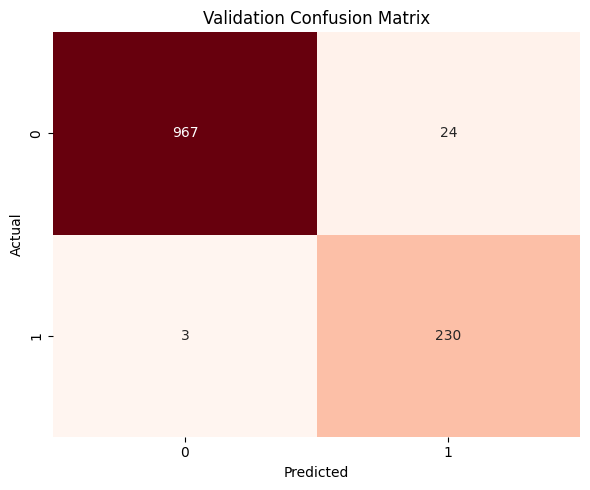

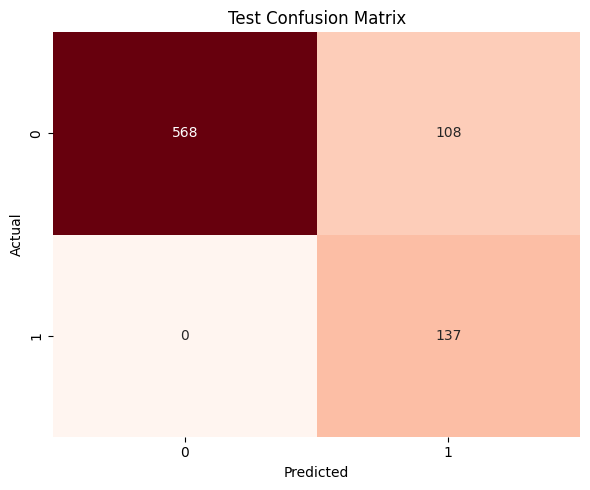

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels=(0, 1), class_names=("Low Risk", "High Risk"), normalize=False, title="Confusion Matrix"):
   
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))

    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
        annot = np.array([[f"{v:.2%}" for v in row] for row in cm])
        fmt = ""
    else:
        annot = True
        fmt = "d"

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt=fmt,
        cmap="Reds",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# 사용 예시 (Validation / Test)
plot_confusion_matrix(valid_true, valid_pred, class_names=("0", "1"), normalize=False, title="Validation Confusion Matrix")
plot_confusion_matrix(test_true, test_pred, class_names=("0", "1"), normalize=False, title="Test Confusion Matrix")

# 정규화(비율) 버전
# plot_confusion_matrix(valid_true, valid_pred, class_names=("0", "1"), normalize=True, title="Validation CM (Normalized)")
# plot_confusion_matrix(test_true, test_pred, class_names=("0", "1"), normalize=True, title="Test CM (Normalized)")